## BC (seq2seq) on SineWaves-v0 (oracle dataset)

This notebook trains a sequence policy via behavioral cloning (BC) from the **oracle** Minari dataset generated by `datasets/discrete/cfg/sine_waves/default.yml`.


In [1]:
import os
import random
import sys
from pathlib import Path
from tqdm import tqdm

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import gymnasium as gym
import matplotlib.pyplot as plt
import minari
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import datasets.discrete.envs.sine_waves  # noqa: F401

DATASET_ID = "SineWaves-v0/oracle-discrete-v0"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
def collate_fn(batch):
    obs_list, actions_list, lengths = [], [], []

    for ep in batch:
        obs = np.asarray(ep.observations, dtype=np.float32)
        T = len(ep.actions)
        obs = obs[:T]
        obs_list.append(torch.from_numpy(obs))
        actions_list.append(torch.as_tensor(ep.actions, dtype=torch.long))
        lengths.append(T)

    B = len(batch)
    max_T = max(lengths)
    obs_dim = int(obs_list[0].shape[-1])

    observations = torch.zeros((B, max_T, obs_dim), dtype=torch.float32)
    actions = torch.full((B, max_T), -1, dtype=torch.long)
    mask = torch.zeros((B, max_T), dtype=torch.bool)

    for i, (obs_i, act_i, T_i) in enumerate(zip(obs_list, actions_list, lengths)):
        observations[i, :T_i] = obs_i
        actions[i, :T_i] = act_i
        mask[i, :T_i] = True

    return {
        "observations": observations,
        "actions": actions,
        "mask": mask,
        "lengths": torch.as_tensor(lengths, dtype=torch.long),
    }


if DATASET_ID not in minari.list_local_datasets():
    raise FileNotFoundError(
        f"Minari dataset {DATASET_ID} not found locally. Build it with: python datasets/discrete/build_dataset/sine_waves.py --config datasets/discrete/cfg/sine_waves/default.yml"
    )

ds = minari.load_dataset(DATASET_ID)
loader_rng = torch.Generator()
loader_rng.manual_seed(SEED)
dataloader = DataLoader(
    ds,
    batch_size=256,
    shuffle=True,
    collate_fn=collate_fn,
    generator=loader_rng,
)

env_tmp = gym.make("SineWaves-v0")
obs_dim = int(np.prod(env_tmp.observation_space.shape))
n_actions = int(env_tmp.action_space.n)
obs_dim, n_actions


/Users/a1111/tiny-rl/.venv/lib/python3.11/site-packages/minari/storage/local.py:109: UserWarning: Misconfigured dataset named MiniGrid-SimpleCrossingS9N1-v0/expert-v1: No data found in data path /Users/a1111/.minari/datasets/MiniGrid-SimpleCrossingS9N1-v0/expert-v1/data
  warnings.warn(f"Misconfigured dataset named {dst_id}: {e}")
/Users/a1111/tiny-rl/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:480: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: []
  logger.warn(


(2, 101)

In [3]:
class GRUPolicy(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, hidden_size: int = 128):
        super().__init__()
        self.rnn = nn.GRU(input_size=obs_dim, hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, n_actions)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        h, _ = self.rnn(obs)
        return self.head(h)


def make_train_val_masks(lengths: torch.Tensor, max_T: int, frac_val: float = 0.1):
    lengths = lengths.to(torch.long)
    B = int(lengths.shape[0])
    train_mask = torch.zeros((B, max_T), dtype=torch.bool)
    val_mask = torch.zeros((B, max_T), dtype=torch.bool)

    for i in range(B):
        T_i = int(lengths[i].item())
        split = int(np.floor((1.0 - frac_val) * T_i))
        split = max(0, min(split, T_i))
        train_mask[i, :split] = True
        val_mask[i, split:T_i] = True

    return train_mask, val_mask



In [6]:
GRID_HEIGHT = 2
GRID_WIDTH = 2

def visualize_action_cells_on_val(
    *,
    model,
    dataset,
    n_actions: int,
    frac_val: float = 0.1,
    seed: int = 0,
    epoch: int | None = None,
    state_dict_path=None,
    state_dict=None,
):
    was_training = model.training
    restore_state_dict = None

    if state_dict_path is not None or state_dict is not None:
        restore_state_dict = {k: v.detach().clone() for k, v in model.state_dict().items()}
        if state_dict is None:
            state_dict = torch.load(state_dict_path, map_location=next(model.parameters()).device)
        model.load_state_dict(state_dict)

    model.eval()
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=GRID_HEIGHT * GRID_WIDTH, replace=False)

    fig, axes = plt.subplots(GRID_HEIGHT, GRID_WIDTH, figsize=(5 * GRID_WIDTH, 4 * GRID_HEIGHT), squeeze=False)

    cmap = plt.matplotlib.colors.ListedColormap(["white", "C0", "C1", "C2"])
    norm = plt.matplotlib.colors.BoundaryNorm([0, 1, 2, 3, 4], cmap.N)

    if epoch is not None:
        fig.suptitle(f"epoch={epoch}")

    for ax, idx in zip(axes.ravel(), idxs):
        ep = dataset[int(idx)]

        obs_all = np.asarray(ep.observations, dtype=np.float32)
        T = int(len(ep.actions))
        if obs_all.shape[0] < T + 1:
            T = max(0, obs_all.shape[0] - 1)

        obs = obs_all[:T]
        target_actions = np.asarray(ep.actions, dtype=np.int64)[:T]

        with torch.no_grad():
            obs_t = torch.from_numpy(obs).view(1, T, -1).to(device)
            logits = model(obs_t)[0]
            pred_actions = torch.argmax(logits, dim=-1).cpu().numpy().astype(np.int64)

        split = int(np.floor((1.0 - frac_val) * T))
        split = max(0, min(split, T))
        val_T = T - split

        grid = np.zeros((n_actions, val_T), dtype=np.uint8)
        for j, t in enumerate(range(split, T)):
            a = int(target_actions[t])
            p = int(pred_actions[t])
            if a == p:
                grid[a, j] = 3
            else:
                grid[a, j] = 1
                grid[p, j] = 2

        ax.imshow(grid, aspect="auto", origin="lower", interpolation="nearest", cmap=cmap, norm=norm)
        ax.set_title(f"episode={int(idx)} val_len={val_T}")
        ax.set_xlabel("val time")
        ax.set_ylabel("action bin")

    import matplotlib.patches as mpatches

    legend_handles = [
        mpatches.Patch(color="C0", label="target"),
        mpatches.Patch(color="C1", label="pred"),
        mpatches.Patch(color="C2", label="match"),
    ]

    fig.legend(handles=legend_handles, loc="upper center", ncol=3)
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    plt.show()

    if restore_state_dict is not None:
        model.load_state_dict(restore_state_dict)
    model.train(was_training)


epoch=950 val_loss=1.003372 best_val_loss=1.003372 bad_epochs=0


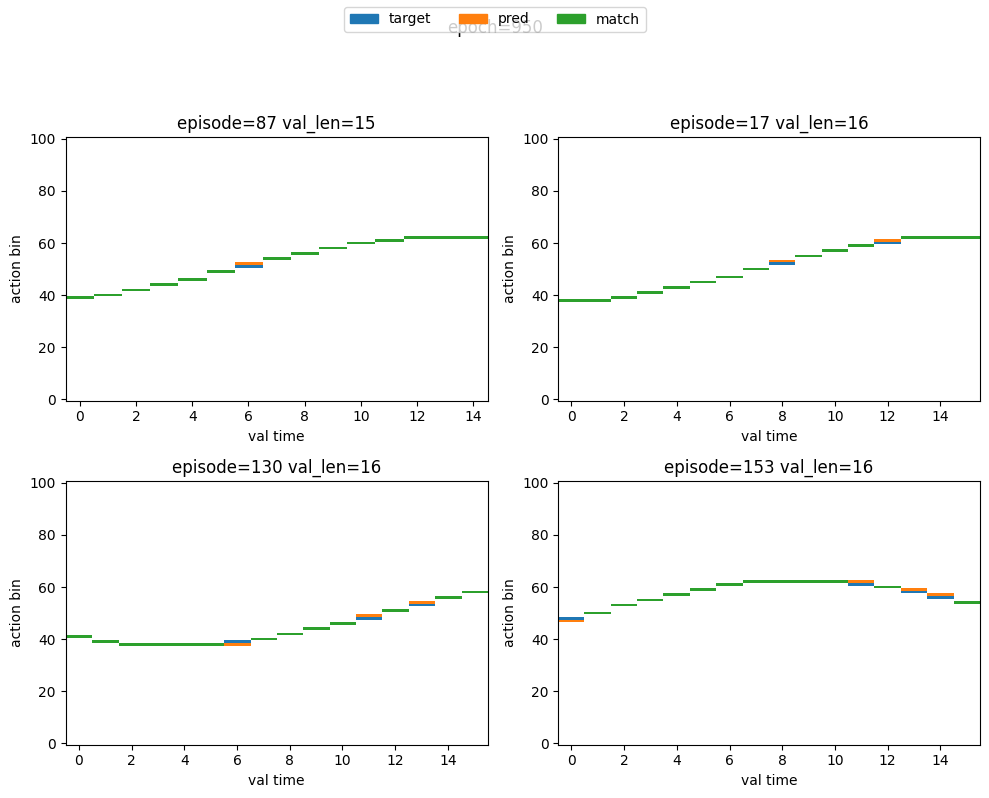

In [7]:
from IPython.display import clear_output

EARLY_STOPPING_METRIC = "val_loss"
PATIENCE_EPOCHS = 10
N_EPOCHS = 1000

EVAL_EVERY_N_EPOCHS = 50

seed_everything(SEED)

config_name = "default"
dataset_name = DATASET_ID.split("/", 1)[1]
best_model_path = Path("data") / "experiments" / "discrete" / dataset_name / config_name / "best_model.pth"
best_model_path.parent.mkdir(parents=True, exist_ok=True)

bc = GRUPolicy(obs_dim=obs_dim, n_actions=n_actions).to(device)
opt = torch.optim.AdamW(bc.parameters(), lr=3e-4)

torch.save(bc.state_dict(), best_model_path)

best_val_loss = float("inf")
best_epoch = -1
bad_epochs = 0

history = []
for epoch in range(N_EPOCHS):
    bc.train()
    val_loss_sum = 0.0
    val_n = 0

    for batch in dataloader:
        obs = batch["observations"].to(device)
        actions = batch["actions"].to(device)
        mask = batch["mask"].to(device)
        lengths = batch["lengths"]

        _, max_T, _ = obs.shape
        train_mask, val_mask = make_train_val_masks(lengths, max_T=max_T, frac_val=0.1)
        train_mask = (train_mask.to(device) & mask)
        val_mask = (val_mask.to(device) & mask)

        logits = bc(obs)
        loss = F.cross_entropy(logits[train_mask], actions[train_mask])

        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            val_logits = logits[val_mask]
            val_actions = actions[val_mask]
            if val_actions.numel() > 0:
                vloss = F.cross_entropy(val_logits, val_actions)
                n_val = int(val_actions.numel())
                val_loss_sum += float(vloss.item()) * n_val
                val_n += n_val

    val_loss = val_loss_sum / max(val_n, 1)
    history.append({"epoch": epoch, "val_loss": val_loss})

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        bad_epochs = 0
        torch.save(bc.state_dict(), best_model_path)
    else:
        bad_epochs += 1

    if epoch % EVAL_EVERY_N_EPOCHS == 0:
        clear_output(wait=True)
        print(f"epoch={epoch} val_loss={val_loss:.6f} best_val_loss={best_val_loss:.6f} bad_epochs={bad_epochs}")
        visualize_action_cells_on_val(model=bc, dataset=ds, n_actions=n_actions, frac_val=0.1, seed=SEED, epoch=epoch)

    if bad_epochs >= PATIENCE_EPOCHS:
        break


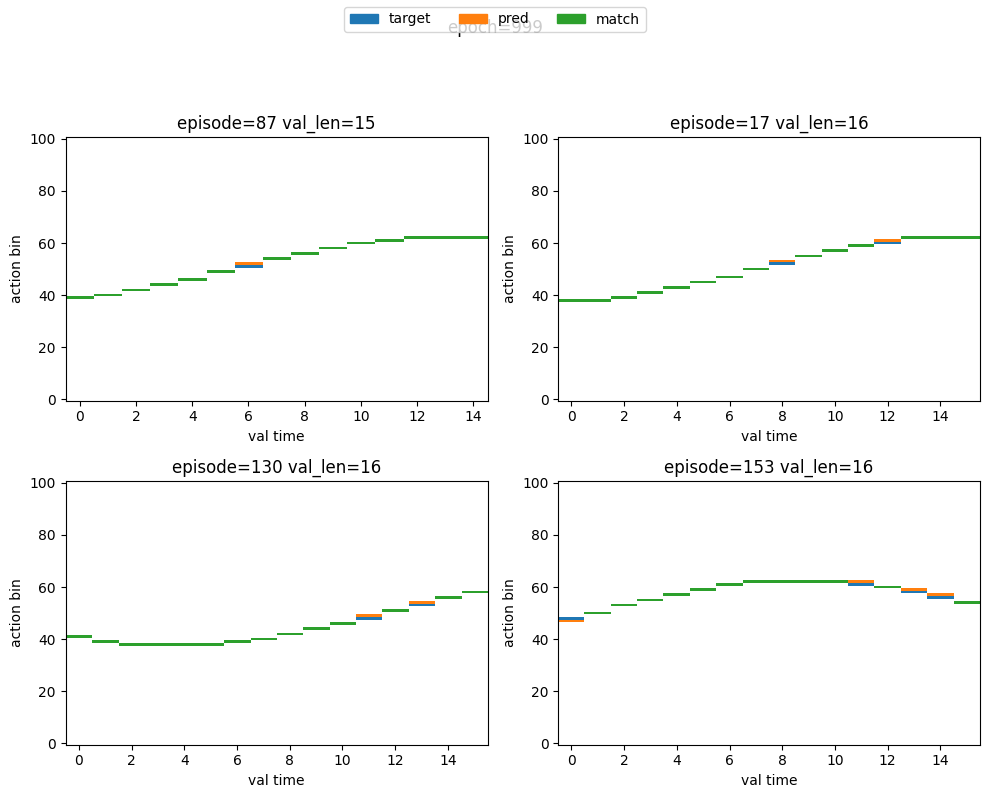

In [8]:
visualize_action_cells_on_val(
    model=bc,
    dataset=ds,
    n_actions=n_actions,
    frac_val=0.1,
    seed=SEED,
    epoch=best_epoch,
    state_dict_path=best_model_path,
)
